In [77]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense , Flatten
import numpy as np

import matplotlib.pyplot as pt
import sklearn as sk
from sklearn import datasets

In [78]:
digits = datasets.load_digits()

In [79]:
digits.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

In [80]:
data =digits['data']
target = digits['target']

In [81]:
X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(data,target,random_state= 42 , test_size=0.25)

In [82]:
X_test= X_test.reshape(-1,8,8)
X_train = X_train.reshape(-1,8,8)

In [83]:
# pt.imshow(X_train[0].reshape(8,8), cmap='gray')
# pt.title(y_train[0])

In [84]:
model = tf.keras.Sequential(
    [
        tf.keras.layers.Flatten(input_shape=(8, 8)),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(150, activation=tf.keras.activations.relu),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(60, activation=tf.keras.activations.relu),
        tf.keras.layers.Dense(10),
    ]
)

In [85]:
model.compile(
    optimizer= 'adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'],
)

In [86]:
# model.summary()

In [87]:
model.fit(X_train,y_train,epochs= 50, validation_split= 0.2 , verbose = 0 ) # , 

In [88]:
model.evaluate(X_test,y_test)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9244 - loss: 0.5075 


[0.5075231194496155, 0.9244444370269775]

In [89]:
model.history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

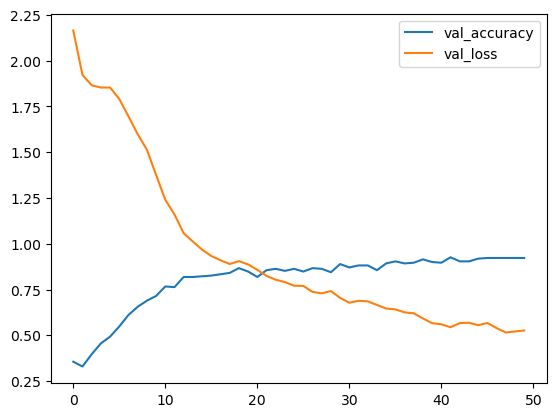

In [90]:
pt.plot(model.history.history['val_accuracy'])
pt.plot(model.history.history['val_loss'])

pt.legend(["val_accuracy" , "val_loss"])

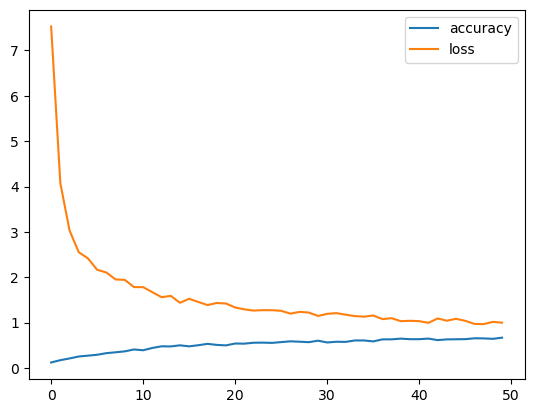

In [91]:
pt.plot(model.history.history['accuracy'])
pt.plot(model.history.history['loss'])

pt.legend(["accuracy" , "loss"])

In [92]:
y_test[5]

np.int64(1)

In [93]:
model.predict(X_test[5].reshape(1,8,8)).argmax()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


np.int64(2)

In [94]:
probabilty_model =tf.keras.Sequential([
    model,tf.keras.layers.Softmax()
    
])

In [95]:
probabilty_model.predict(X_test[5].reshape(1,8,8)).argmax()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


np.int64(2)